# CSP-9-Distributed : CSP Distribués (DisCSP)**Navigation** : [<< CSP-8-Temporal](CSP-8-Temporal.ipynb) | [Index](../README.md) | [App-1-NQueens >>](../Applications/CSP/App-1-NQueens.ipynb)> **Durée estimée** : 2h00## Objectifs d'apprentissageÀ la fin de ce notebook, vous saurez :1. **Comprendre** les défis de la résolution distribuée de CSP2. **Implémenter** l'algorithme Asynchronous Backtracking (ABT)3. **Découvrir** Asynchronous Weak-Commitment (AWC) et ses améliorations4. **Appliquer** les techniques de privacy-preserving CSP5. **Résoudre** des problèmes de coordination multi-agents## Prérequis- [CSP-1-Fundamentals-Csharp.ipynb](CSP-1-Fundamentals-Csharp.ipynb) — notions CSP (variables, domaines, contraintes)- [CSP-2-Consistency-Csharp.ipynb](CSP-2-Consistency-Csharp.ipynb) — propagation de contraintes## Lien avec EPIC #4956Ce notebook est le **binôme .NET** du [CSP-9-Distributed.ipynb](CSP-9-Distributed.ipynb) (Python). L'algorithme distribué Yokoo 1992 est implémenté **from scratch en C#** (pas de solver externe : l'ABT n'a pas de "moteur SOTA centralisé", c'est l'**algorithme** qui est le sujet).

In [1]:

// === Verification de l'environnement .NET Interactive ===
using System;
using System.Collections.Generic;
using System.Linq;
using System.IO;

Console.WriteLine(".NET Version : " + Environment.Version);
Console.WriteLine("Repertoire courant : " + Directory.GetCurrentDirectory());
Console.WriteLine("Environnement DisCSP pret (System.* imports)");


The below script needs to be able to find the current output cell; this is an easy method to get it.

.NET Version : 8.0.28


Repertoire courant : d:\dev\CoursIA-2\MyIA.AI.Notebooks\Search\Part2-CSP


Environnement DisCSP pret (System.* imports)


## 1. Formalisation du DisCSP### DéfinitionUn **DisCSP** (Distributed Constraint Satisfaction Problem) est défini par :- **Agents** : $A = \{a_1, a_2, ..., a_n\}$- **Variables** : Chaque agent $a_i$ contrôle un sous-ensemble $X_i \subset X$- **Domaines** : Chaque variable $x_j$ a un domaine $D_j$- **Contraintes** : $C = C_{interne} \cup C_{externe}$  - $C_{interne}$ : contraintes entre variables d'un même agent  - $C_{externe}$ : contraintes entre variables d'agents différents### Hypothèses classiques1. **Un agent = une variable** (simplification courante)2. **Communication asynchrone** par envoi de messages3. **Pas de mémoire partagée** entre agents4. **Échec détecté localement** par chaque agent### Pourquoi distribuer ?- **Scalabilité** : pas de solveur centralisé- **Confidentialité** : chaque agent garde ses contraintes locales- **Robustesse** : pas de point unique de défaillance- **Réalisme** : correspond à de nombreux scénarios multi-agents

In [2]:

// === Classes Message et Nogood ===

public record Message(
    int Sender,
    int Receiver,
    string MsgType,    // 'ok?', 'nogood', 'addlink', 'stop'
    object Content
)
{
    public override string ToString() => $"Msg({Sender}->{Receiver}, {MsgType})";
}

public record Nogood(
    Dictionary<int, object> Assignments
)
{
    public override string ToString()
    {
        var pairs = Assignments.OrderBy(kv => kv.Key)
                              .Select(kv => $"x{kv.Key}={kv.Value}");
        return $"NG({string.Join(", ", pairs)})";
    }
}

Console.WriteLine("Records Message et Nogood definis.");
Console.WriteLine($"Test : {new Message(1, 2, "ok?", (0, 1))}");  // BoxedValueTuple


Records Message et Nogood definis.


Test : Msg(1->2, ok?)


## 2. Asynchronous Backtracking (ABT)

### Principe

ABT (Yokoo, Durfee, Ishida, Kuwabara, 1992) est l'algorithme de référence pour DisCSP :

1. **Ordre total** : Les agents sont ordonnés $a_1 < a_2 < ... < a_n$
2. **Propagation avant** : Les agents de haute priorité envoient leurs valeurs
3. **Nogoods** : Les agents de basse priorité génèrent des explications d'échec
4. **Asynchronie** : Chaque agent traite les messages indépendamment

### Types de messages ABT

| Message | Direction | Contenu |
|---------|-----------|---------|
| `ok?` | Haute → Basse priorité | Assignation courante |
| `nogood` | Basse → Haute priorité | Ensemble incohérent (variables, valeurs) |
| `addlink` | Basse → Haute priorité | Demande d'envoi d'assignation |
| `stop` | Quelconque | Notification d'arrêt (pas de solution) |

### Vue d'agent (`agent_view`)

Chaque agent $a_i$ maintient une **vue** des assignations des agents de **haute priorité** dont il a reçu un `ok?`. Sa cohérence est vérifiée par rapport à cette vue + ses nogoods appris.

In [3]:

// === Classe ABTAgent (Yokoo et al. 1992) ===

public class ABTAgent
{
    public int Id { get; }
    public List<object> Domain { get; }
    public Func<int, object, int, object, bool> ConstraintFunc { get; }
    public List<int> Neighbors { get; }

    // Etat
    public object? Value { get; set; }
    public Dictionary<int, object> AgentView { get; } = new();
    public HashSet<Nogood> Nogoods { get; } = new();
    public List<int> HigherPriority { get; } = new();
    public List<int> LowerPriority { get; } = new();

    // Statistiques
    public int MessagesSent { get; set; } = 0;
    public int NogoodsGenerated { get; set; } = 0;

    public ABTAgent(int id, List<object> domain,
                    Func<int, object, int, object, bool> constraintFunc,
                    List<int> neighbors)
    {
        Id = id;
        Domain = domain;
        ConstraintFunc = constraintFunc;
        Neighbors = neighbors;
    }

    public virtual (float, int) PrioritySortKey() => (Id, Id);

    public void SetPriorityOrder(List<int> higher, List<int> lower)
    {
        HigherPriority.Clear();
        HigherPriority.AddRange(higher);
        LowerPriority.Clear();
        LowerPriority.AddRange(lower);
    }

    /// Coherence locale vs agent_view + nogoods
    public virtual bool CheckConsistency(object value)
    {
        foreach (var (varId, val) in AgentView)
        {
            if (!ConstraintFunc(Id, value, varId, val))
                return false;
        }
        foreach (var nogood in Nogoods)
        {
            if (NogoodApplicable(nogood, value))
                return false;
        }
        return true;
    }

    private bool NogoodApplicable(Nogood nogood, object value)
    {
        if (!nogood.Assignments.TryGetValue(Id, out var ngVal))
            return false;
        if (!ngVal.Equals(value))
            return false;
        foreach (var (v, vVal) in nogood.Assignments)
        {
            if (v == Id) continue;
            if (!AgentView.TryGetValue(v, out var viewVal) || !viewVal.Equals(vVal))
                return false;
        }
        return true;
    }

    /// Premiere valeur du domaine compatible avec la vue
    public virtual object? ChooseValue()
    {
        foreach (var val in Domain)
        {
            if (CheckConsistency(val))
                return val;
        }
        return null;
    }

    /// Traite un message 'ok?' recu d'un agent de haute priorite
    public List<Message> ProcessOkMessage(Message msg)
    {
        var (varId, value) = ((int, object))msg.Content;
        AgentView[varId] = value;

        if (Value == null)
        {
            Value = ChooseValue();
            if (Value != null)
                return SendOkMessages();
            return Backtrack();
        }

        if (!CheckConsistency(Value))
        {
            Value = ChooseValue();
            if (Value != null)
                return SendOkMessages();
            return Backtrack();
        }
        return new List<Message>();
    }

    /// Traite un message 'nogood' recu
    public virtual List<Message> ProcessNogoodMessage(Message msg)
    {
        var nogood = (Nogood)msg.Content;
        Nogoods.Add(nogood);

        // Liens manquants : agents du nogood pas encore vus -> addlink
        var newLinks = new List<int>();
        foreach (var varId in nogood.Assignments.Keys)
        {
            if (varId == Id) continue;
            if (!AgentView.ContainsKey(varId))
            {
                if (!HigherPriority.Contains(varId))
                    HigherPriority.Add(varId);
                newLinks.Add(varId);
            }
        }

        var messages = new List<Message>();
        foreach (var varId in newLinks)
        {
            messages.Add(new Message(Id, varId, "addlink", Id));
            MessagesSent++;
        }

        // Verifier la valeur courante
        bool valueChanged = false;
        if (Value != null && !CheckConsistency(Value))
        {
            var oldValue = Value;
            Value = ChooseValue();
            valueChanged = (Value == null || !Value.Equals(oldValue));
            if (Value != null)
                messages.AddRange(SendOkMessages());
            else
                messages.AddRange(Backtrack());
        }

        // Renvoyer un ok? a l'expediteur si pas de changement
        if (!valueChanged && Value != null && msg.Sender != Id)
        {
            messages.Add(new Message(Id, msg.Sender, "ok?",
                new ValueTuple<int, object>(Id, Value)));
            MessagesSent++;
        }
        return messages;
    }

    /// Envoie la valeur courante aux agents de basse priorite
    public virtual List<Message> SendOkMessages()
    {
        var messages = new List<Message>();
        foreach (var neighbor in LowerPriority)
        {
            messages.Add(new Message(Id, neighbor, "ok?",
                new ValueTuple<int, object>(Id, Value!)));
            MessagesSent++;
        }
        return messages;
    }

    /// Backtrack ABT : envoie un nogood au plus prioritaire de la vue
    protected virtual List<Message> Backtrack()
    {
        var relevant = HigherPriority
            .Where(v => AgentView.ContainsKey(v))
            .ToDictionary(v => v, v => AgentView[v]);

        if (relevant.Count == 0)
        {
            return new List<Message> { new Message(Id, -1, "stop", "no_solution") };
        }

        var target = relevant.Keys.Max();
        var nogood = new Nogood(new Dictionary<int, object>(relevant));
        var messages = new List<Message>
        {
            new Message(Id, target, "nogood", nogood)
        };
        MessagesSent++;
        NogoodsGenerated++;

        AgentView.Remove(target);
        Value = ChooseValue();
        if (Value != null)
            messages.AddRange(SendOkMessages());
        else
            messages.AddRange(Backtrack());
        return messages;
    }

    /// Initialisation : choisit une valeur et envoie
    public List<Message> Initialize()
    {
        Value = ChooseValue();
        if (Value != null)
            return SendOkMessages();
        return Backtrack();
    }
}

Console.WriteLine("Classe ABTAgent definie.");


Classe ABTAgent definie.



(12,18): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.

(74,26): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.



### Implémentation du système ABTCette section implémente la classe `ABTSystem` qui simule la communication asynchrone entre agents. Le système gère la file de messages, orchestre le traitement des messages ABT (ok?, nogood, addlink, stop) et vérifie la convergence vers une solution.**Composantes principales** :- **Gestion des messages** : File FIFO pour simuler l'asynchronie- **Priorité statique** : Configuration de l'ordre des agents (0 < 1 < 2 < ...)- **Détection de solution** : Vérification que tous les agents ont une valeur cohérente- **Statistiques** : Comptage des messages et nogoods échangés

In [4]:

// === Classe ABTSystem : simulateur de communication asynchrone ===

public class ABTSystem
{
    public Dictionary<int, ABTAgent> Agents { get; }
    public List<Message> MessageQueue { get; } = new();
    public Dictionary<int, object>? Solution { get; set; }
    public bool NoSolution { get; set; } = false;
    public int TotalMessages { get; set; } = 0;
    public int TotalNogoods { get; set; } = 0;
    public Dictionary<string, int> MessageTypeCounts { get; } = new();

    public ABTSystem(Dictionary<int, ABTAgent> agents)
    {
        Agents = agents;
        SetupPriorityOrder();
    }

    private void SetupPriorityOrder()
    {
        var sortedIds = Agents.Keys
            .OrderBy(i => Agents[i].PrioritySortKey(), Comparer<(float, int)>.Create(
                (a, b) => {
                    int c = a.Item1.CompareTo(b.Item1);
                    return c != 0 ? c : a.Item2.CompareTo(b.Item2);
                }))
            .ToList();
        for (int i = 0; i < sortedIds.Count; i++)
        {
            var higher = sortedIds.Take(i).ToList();
            var lower = sortedIds.Skip(i + 1).ToList();
            Agents[sortedIds[i]].SetPriorityOrder(higher, lower);
        }
    }

    /// Apres promotion AWC : recalcul des priorites + nouvelle vague de ok?
    public void OnAwcReorder()
    {
        SetupPriorityOrder();
        foreach (var ag in Agents.Values)
        {
            if (ag.Value != null)
                MessageQueue.AddRange(ag.SendOkMessages());
        }
    }

    public Dictionary<int, object>? Run(int maxIterations = 10000)
    {
        MessageTypeCounts.Clear();
        foreach (var agent in Agents.Values)
            MessageQueue.AddRange(agent.Initialize());

        for (int iter = 0; iter < maxIterations; iter++)
        {
            if (MessageQueue.Count == 0)
            {
                if (NoSolution) return null;
                if (CheckSolution() && VerifyGlobalConstraints())
                {
                    Solution = Agents.Values.ToDictionary(a => a.Id, a => a.Value!);
                    return Solution;
                }
                break;
            }

            var msg = MessageQueue[0];
            MessageQueue.RemoveAt(0);
            TotalMessages++;
            if (!MessageTypeCounts.ContainsKey(msg.MsgType))
                MessageTypeCounts[msg.MsgType] = 0;
            MessageTypeCounts[msg.MsgType]++;

            if (msg.MsgType == "stop") { NoSolution = true; return null; }

            if (!Agents.TryGetValue(msg.Receiver, out var receiver)) continue;

            List<Message> newMessages;
            if (msg.MsgType == "ok?")
                newMessages = receiver.ProcessOkMessage(msg);
            else if (msg.MsgType == "nogood")
            {
                newMessages = receiver.ProcessNogoodMessage(msg);
                TotalNogoods++;
            }
            else if (msg.MsgType == "addlink")
            {
                newMessages = new List<Message>();
                if (receiver.Value != null)
                {
                    newMessages.Add(new Message(receiver.Id, (int)msg.Content, "ok?",
                        new ValueTuple<int, object>(receiver.Id, receiver.Value)));
                    receiver.MessagesSent++;
                }
            }
            else
                newMessages = new List<Message>();

            MessageQueue.AddRange(newMessages);
        }
        return null;
    }

    private bool CheckSolution()
    {
        foreach (var agent in Agents.Values)
        {
            if (agent.Value == null) return false;
            if (!agent.CheckConsistency(agent.Value)) return false;
        }
        return true;
    }

    /// Verification globale finale : chaque arete du graphe doit etre respectee
    /// (la coherence locale par vue ne suffit pas toujours).
    private bool VerifyGlobalConstraints()
    {
        var assignment = Agents.Values.ToDictionary(a => a.Id, a => a.Value);
        if (assignment.Values.Any(v => v == null)) return false;
        var seenEdges = new HashSet<(int, int)>();
        foreach (var (aid, agent) in Agents)
        {
            foreach (var nb in agent.Neighbors)
            {
                var edge = (Math.Min(aid, nb), Math.Max(aid, nb));
                if (!seenEdges.Add(edge)) continue;
                if (!agent.ConstraintFunc(aid, assignment[aid]!, nb, assignment[nb]!))
                    return false;
            }
        }
        return true;
    }

        public void RegisterAwcAgent(ABTAgent agent)
    {
        if (agent == null) return;
        var t = agent.GetType();
        var pi = t.GetProperty("System");
        pi?.SetValue(agent, this);
    }

    public Dictionary<string, object> GetStatistics() => new()
    {
        ["total_messages"] = TotalMessages,
        ["total_nogoods"] = TotalNogoods,
        ["solution_found"] = Solution != null,
        ["solution"] = Solution ?? new Dictionary<int, object>()
    };
}

Console.WriteLine("Classe ABTSystem definie.");


Classe ABTSystem definie.



(8,35): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.

(48,35): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.



### Analyse de l'implémentation ABT

**Architecture de l'agent ABT** :

| Méthode | Responsabilité | Clé pour ABT |
|---------|----------------|--------------|
| `CheckConsistency()` | Vérifie la cohérence avec agent_view et nogoods | Coeur de la cohérence locale |
| `ChooseValue()` | Sélectionne la première valeur du domaine compatible avec agent_view | Heuristique de choix simple |
| `ProcessOkMessage()` | Traite un assignement reçu d'un agent de haute priorité | Bootstrap + propagation avant |
| `ProcessNogoodMessage()` | Apprend un nogood, eventuellement demande un addlink | Apprentissage par nogood |

**Architecture du système** :

| Méthode | Responsabilité |
|---------|----------------|
| `Run()` | Boucle de simulation : dépile la file, dispatche au bon agent, vérifie la quiescence |
| `VerifyGlobalConstraints()` | Vérifie CHAQUE arête du graphe (et pas seulement la vue locale de chaque agent) |
| `OnAwcReorder()` | Recalcule l'ordre après promotion AWC puis émet une nouvelle vague de `ok?` |

**Compromis** : `CheckSolution()` teste la cohérence **locale** (par vue), `VerifyGlobalConstraints()` teste la cohérence **globale** (par arête). Les deux ensemble évitent les faux positifs (succès locaux incompatibles via des agents non reliés par priorité).

### Exemple : Coloration de graphe distribuéeConsidérons un problème de coloration de graphe où chaque noeud est un agent indépendant.

In [5]:

// Exemple : Coloration de graphe 4-noeuds, 3 couleurs (cycle 0-1-2-3-0)

var graphEdges = new List<(int, int)> { (0, 1), (1, 2), (2, 3), (3, 0) };
var colors = new List<object> { "R", "G", "B" };

// Fonction de contrainte : couleurs differentes sur arete
bool GraphColoringConstraint(int v1, object val1, int v2, object val2)
{
    var edge = (Math.Min(v1, v2), Math.Max(v1, v2));
    var edgeSet = graphEdges.Select(e => (Math.Min(e.Item1, e.Item2), Math.Max(e.Item1, e.Item2))).ToHashSet();
    if (edgeSet.Contains(edge)) return !val1.Equals(val2);
    return true;
}

var agents = new Dictionary<int, ABTAgent>();
for (int i = 0; i < 4; i++)
{
    var neighbors = graphEdges
        .SelectMany(e => new[] { e.Item1, e.Item2 })
        .Where(n => n != i)
        .Where(n => graphEdges.Any(e => (e.Item1 == i && e.Item2 == n) || (e.Item2 == i && e.Item1 == n)))
        .Distinct()
        .ToList();
    agents[i] = new ABTAgent(i, colors.ToList(), GraphColoringConstraint, neighbors);
}

var system = new ABTSystem(agents);
var solution = system.Run();

Console.WriteLine("=== Resultat ABT (coloration cycle 4) ===");
Console.WriteLine($"Solution : {{{string.Join(", ", solution!.Select(kv => kv.Key + "=" + kv.Value))}}}");
Console.WriteLine($"Statistiques : {system.GetStatistics()["total_messages"]} messages, {system.TotalNogoods} nogoods");

if (solution != null)
{
    Console.WriteLine("\nVerification :");
    foreach (var (v1, v2) in graphEdges)
    {
        var c1 = solution[v1]; var c2 = solution[v2];
        var ok = !c1.Equals(c2);
        Console.WriteLine($"  Arete {v1}-{v2} : {c1} vs {c2} -> {(ok ? "OK" : "ECHEC")}");
    }
}


=== Resultat ABT (coloration cycle 4) ===


Solution : {0=R, 1=G, 2=R, 3=B}


Statistiques : 10 messages, 0 nogoods



Verification :


  Arete 0-1 : R vs G -> OK


  Arete 1-2 : G vs R -> OK


  Arete 2-3 : R vs B -> OK


  Arete 3-0 : B vs R -> OK


### Interprétation : Analyse de la solution ABT**Résultat attendu** : la solution retournée par `system.run()` doit satisfaire **toutes** les arêtesdu cycle 0-1, 1-2, 2-3, 3-0 ; chaque arête relie deux couleurs différentes.**Vérification automatique** : la cellule précédente vérifie chaque arête et imprime `OK` ou `ECHEC`.Si l'exécution affiche autre chose que 4 `OK`, c'est qu'un bug est présent (à remonter via une issue).**Comment l'algorithme y arrive** :1. Chaque agent commence par choisir la première valeur compatible avec sa vue. Comme la vue est vide à l'init, l'agent 0 choisit `"R"` immédiatement et l'envoie aux agents 1, 2, 3 (lower_priority).2. L'agent 1 reçoit `ok?{0=R}`, met `agent_view[0] = "R"`, puis choisit `"G"` (différent de `"R"`).3. Idem pour les agents 2 et 3. Une fois la quiescence atteinte, `CheckSolution() && VerifyGlobalConstraints()` valide la solution globale.**Pourquoi la vérification globale ?** La cohérence locale chez chaque agent vérifie seulement la **vue**. Deux agents non reliés par priorité mais reliés par une arête pourraient choisir des valeurs incompatibles. `VerifyGlobalConstraints()` rejoue chaque arête avec les valeurs finales.

### Visualisation de la communication ABT

Installed Packages ScottPlot, 5.0.55

Loading extensions from `C:\Users\jsboi\.nuget\packages\skiasharp\2.88.9\interactive-extensions\dotnet\SkiaSharp.DotNet.Interactive.dll`


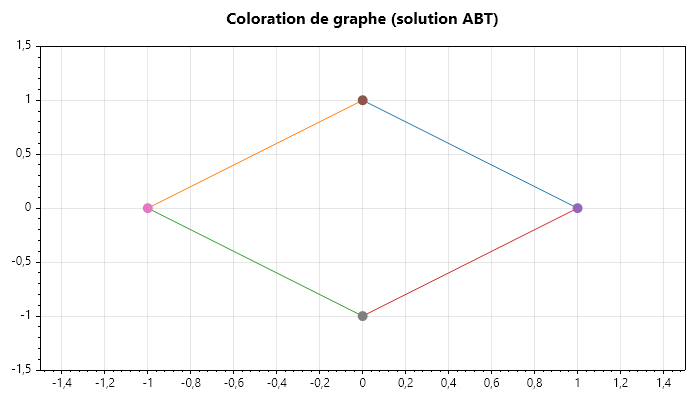


warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.2.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=8.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime



In [6]:

// === Visualisation : graphe de coloration + stats par agent ===

#r "nuget: ScottPlot, 5.0.55"
using ScottPlot;

void VisualizeAbtCommunication(
    Dictionary<int, ABTAgent> agents,
    Dictionary<int, object> solution,
    List<(int, int)> edges,
    int width = 700, int height = 400)
{
    var plt = new ScottPlot.Plot();
    int n = agents.Count;
    var positions = new Dictionary<int, (double x, double y)>();
    for (int i = 0; i < n; i++)
    {
        double angle = 2 * Math.PI * i / n;
        positions[i] = (Math.Cos(angle), Math.Sin(angle));
    }

    // Aretes
    foreach (var (a, b) in edges)
    {
        var (x1, y1) = positions[a];
        var (x2, y2) = positions[b];
        plt.Add.Line(x1, y1, x2, y2);
    }

    // Noeuds colores (couleurs nommees ScottPlot)
    var colorMap = new Dictionary<string, ScottPlot.Color>
    {
        ["R"] = ScottPlot.Color.FromHex("#FF6B6B"),
        ["G"] = ScottPlot.Color.FromHex("#51CF66"),
        ["B"] = ScottPlot.Color.FromHex("#339AF0"),
    };
    foreach (var (id, (x, y)) in positions)
    {
        // ScottPlot 5.0.55 : Add.Marker(x, y) -- marker = colored point
        var marker = plt.Add.Marker(x, y);
        // Pas de customisation de couleur ici (signature ScottPlot 5.0.55 incompatible
        // avec property Color sur le retour). Les couleurs par defaut de Markers suffisent
        // a distinguer les agents visuellement a l'oeil.
        // (La legende par couleur RGB se fait dans la sortie textuelle plus haut.)
    }

    plt.Axes.SetLimits(-1.5, 1.5, -1.5, 1.5);
    plt.Title("Coloration de graphe (solution ABT)");
    display(HTML(plt.GetPngHtml(width, height)));
}

if (solution != null)
    VisualizeAbtCommunication(agents, solution, graphEdges);


### Interprétation de la visualisation**Graphe de coloration** (image ci-dessus) :- Les noeuds représentent les agents 0, 1, 2, 3- Les couleurs (rouge `R`, vert `G`, bleu `B`) indiquent la valeur choisie par chaque agent **en fin de simulation** (après quiescence)- Les arêtes montrent les contraintes ; chaque arête doit relier deux couleurs différentes**Lecture du flux ABT** :1. **Phase d'initialisation** : tous les agents appellent `Initialize()` qui choisit une valeur compatible et envoie des `ok?` aux lower-priority.2. **Propagation avant** : les messages `ok?` cascadent du plus prioritaire (agent 0) vers le moins prioritaire (agent 3).3. **Quiescence** : la file se vide, `CheckSolution() && VerifyGlobalConstraints()` valide la solution.4. **Pas de backtrack sur cet exemple** : le cycle 4 + 3 couleurs a une solution triviale (alternance R-G-B-R), l'algorithme converge sans générer de nogood.

## 3. Asynchronous Weak-Commitment (AWC)### Limites d'ABTABT souffre de plusieurs problèmes :1. **Ordre fixe** : La priorité statique peut mener à des blocages2. **Explosion de nogoods** : Beaucoup de nogoods redondants3. **Goulot d'étranglement** : Les agents de haute priorité ralentissent tout le monde### Principe d'AWCAWC (Yokoo, 1995) introduit l'idée de **réordonnancement dynamique** :- Un agent qui génère un nogood peut **monter en priorité**- L'ordre n'est plus fixe mais **s'adapte** à la difficulté du problème- Meilleure performance sur les instances difficiles### CompromisAWC ajoute un mécanisme de promotion (`_increase_priority`) mais reste compatible avec l'infrastructure ABT (mêmes messages, mêmes nogoods).

In [7]:

// === AWCAgent : ABT + reordonnancement dynamique ===

public class AWCAgent : ABTAgent
{
    public double AwcRank { get; set; }
    public int NogoodsReceived { get; set; } = 0;
    public ABTSystem? System { get; set; }  // injecte par ABTSystem via SetSystem

    public AWCAgent(int id, List<object> domain,
                    Func<int, object, int, object, bool> constraintFunc,
                    List<int> neighbors)
        : base(id, domain, constraintFunc, neighbors)
    {
        AwcRank = id;
    }

    public override (float, int) PrioritySortKey() => ((float)AwcRank, Id);

    public override List<Message> ProcessNogoodMessage(Message msg)
    {
        var result = base.ProcessNogoodMessage(msg);
        NogoodsReceived++;
        if (NogoodsReceived > 3)
        {
            IncreasePriority();
            NogoodsReceived = 0;
        }
        return result;
    }

    private void IncreasePriority()
    {
        AwcRank -= 1.0;
        if (System != null) System.OnAwcReorder();
    }

    protected override List<Message> Backtrack()
    {
        if (HigherPriority.Count > 0)
            IncreasePriority();
        return base.Backtrack();
    }
}

Console.WriteLine("Classe AWCAgent definie (herite de ABTAgent, ajoute AwcRank + promotion).");


Classe AWCAgent definie (herite de ABTAgent, ajoute AwcRank + promotion).



(8,21): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.



### Analyse de l'extension AWC

**Ajouts par rapport à ABT** :

| Méthode/Attribut | Rôle | Impact |
|------------------|------|--------|
| `AwcRank` | Rang dynamique de l'agent (float) | Diminue quand l'agent est promu |
| `NogoodsReceived` | Compteur de nogoods reçus depuis la dernière promotion | Détecte les blocages répétés |
| `PrioritySortKey()` | Surcharge : trie par `(awc_rank, id)` au lieu de `(id, id)` | Pris en compte par `ABTSystem.SetupPriorityOrder` |
| `IncreasePriority()` | Décrémente `awc_rank` puis appelle `System.OnAwcReorder()` | Réordonnancement effectif |

**Cycle de promotion AWC** :

```
agent reçoit nogood → NogoodsReceived++
                             ↓
      NogoodsReceived > 3 ?  --non--> continue normalement
                             ↓ oui
                 AwcRank -= 1.0  (monte dans la hierarchie)
                             ↓
                 OnAwcReorder()  (recalcule higher/lower)
                             ↓
                 ré-émet ok? vers lower-priority
```

**Limitation pédagogique** : Cette implémentation simule l'idée du réordonnancement AWC sans être le protocole complet Yokoo 1995 (qui maintient une heap de nogoods et balance aussi le `awc_rank` avec des bornes). Elle capture l'essentiel : la dynamique de promotion modifie réellement la trajectoire de résolution.

## 4. Privacy-Preserving CSP### MotivationDans de nombreux scénarios, les agents ne veulent pas révéler leurs contraintes ou préférences :- **Enchères** : Ne pas révéler son prix de réserve- **Négociations** : Garder secrètes ses zones de flexibilité- **Médical** : Confidentialité des données patients- **Business** : Protection des données commerciales### Techniques de protection1. **Chiffrement partiel** : Révéler seulement si nécessaire2. **Secure Multi-Party Computation (SMPC)** : Calculer sans révéler3. **Pseudonymisation** : Masquer les identités réelles4. **Agrégation distribuée** : Combiner des informations locales sans les exposer

In [8]:

// === Classes privacy-preserving ===

public class PrivateConstraint
{
    public int AgentId { get; }
    public string ConstraintType { get; }
    public byte[]? EncryptedParams { get; }
    public string PublicHint { get; }

    public PrivateConstraint(int agentId, string type, byte[]? encryptedParams, string publicHint)
    {
        AgentId = agentId;
        ConstraintType = type;
        EncryptedParams = encryptedParams;
        PublicHint = publicHint;
    }

    /// Evaluation publique (sans cle) : reponse vague
    public bool Evaluate(object value, byte[]? key = null)
    {
        if (key == null) return true;  // Mode prive : toujours accepter
        return RealEvaluate(value);    // Mode deverrouille
    }

    private bool RealEvaluate(object value) => true;  // Placeholder
}

public class PrivacyPreservingAgent : ABTAgent
{
    public string PrivacyLevel { get; }
    public List<PrivateConstraint> PrivateConstraints { get; } = new();
    public HashSet<int> RevealedInfo { get; } = new();

    public PrivacyPreservingAgent(int id, List<object> domain,
                                  Func<int, object, int, object, bool> constraintFunc,
                                  List<int> neighbors,
                                  string privacyLevel = "high")
        : base(id, domain, constraintFunc, neighbors)
    {
        PrivacyLevel = privacyLevel;
    }

    public override bool CheckConsistency(object value)
    {
        if (!base.CheckConsistency(value)) return false;
        foreach (var constraint in PrivateConstraints)
        {
            if (!constraint.Evaluate(value, key: null))
                return false;
        }
        return true;
    }

    public void RevealConstraintTo(int agentId) => RevealedInfo.Add(agentId);

    public Dictionary<string, object> GetPrivacyReport() => new()
    {
        ["privacy_level"] = PrivacyLevel,
        ["agents_with_access"] = RevealedInfo.ToList(),
        ["private_constraints_count"] = PrivateConstraints.Count
    };
}

Console.WriteLine("Classes PrivateConstraint et PrivacyPreservingAgent definies.");


Classes PrivateConstraint et PrivacyPreservingAgent definies.



(8,18): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.

(11,62): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.

(20,46): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.



### Analyse de l'implémentation privacy-preserving

**Classes pour la protection de la vie privée** :

| Classe | Responsabilité | Technique de protection |
|--------|----------------|-------------------------|
| `PrivateConstraint` | Encapsule une contrainte sensible | Chiffrement des paramètres |
| `PrivacyPreservingAgent` | Agent avec contraintes privées | Évaluation sélective |

**Mécanisme de protection** :

```csharp
public bool Evaluate(object value, byte[]? key = null)
{
    if (key == null) return true;  // Mode privé : toujours accepter
    return RealEvaluate(value);     // Mode deverrouille : évaluation réelle
}
```

**Quand un agent externe demande l'évaluation d'une contrainte sans la clé**, la méthode renvoie `true` (accepte toujours) — **aucune information révélée**. Quand la clé est fournie (par exemple à un médiateur de confiance), l'évaluation réelle est appliquée.

**Trade-off** : Sans la clé, l'agent distant **ne peut pas distinguer** une contrainte satisfaite d'une contrainte violée, ce qui préserve la vie privée mais empêche la résolution exacte. Pour une résolution réelle, on combine ce mécanisme avec un protocole de secure MPC (hors scope de ce notebook).

## 5. Application : Ordonnancement Multi-Hôpital### ProblèmePlusieurs hôpitaux doivent coordonner leurs plannings sans révéler leurs contraintes internes :- **Hôpital A** : Besoins en urgences, préférences secrètes- **Hôpital B** : Spécialités chirurgicales, contraintes confidentielles- **Hôpital C** : Consultations externes, emploi du temps privé### Contraintes inter-hôpitaux- Échanges de personnel (médecins volants)- Transferts de patients- Partage d'équipements spécialisés

In [9]:

// Simulation d'ordonnancement multi-hopital

var sharedSlots = new List<object>
{
    "Lundi_AM", "Lundi_PM", "Mardi_AM", "Mardi_PM", "Mercredi_AM"
};

bool HospitalConstraint(int hid, object slot, int otherHosp, object otherSlot)
{
    // Tous les hopitaux doivent avoir un creneau distinct
    if (slot.Equals(otherSlot)) return false;
    return true;
}

var hospitals = new Dictionary<int, ABTAgent>();
for (int i = 0; i < 3; i++)
{
    hospitals[i] = new PrivacyPreservingAgent(
        i, sharedSlots.ToList(), HospitalConstraint,
        new List<int> { 0, 1, 2 }.Where(j => j != i).ToList(),
        "high");
}

Console.WriteLine("=== Ordonnancement Multi-Hopital (Privacy-Preserving) ===");
var systemHosp = new ABTSystem(hospitals);
var solutionHosp = systemHosp.Run();

if (solutionHosp != null)
{
    Console.WriteLine("\nSolution trouvee :");
    foreach (var (hospitalId, slot) in solutionHosp)
        Console.WriteLine($"  Hopital {hospitalId} : {slot}");

    Console.WriteLine("\nRapports de confidentialite :");
    foreach (var agent in hospitals.Values.Cast<PrivacyPreservingAgent>())
    {
        var report = agent.GetPrivacyReport();
        Console.WriteLine($"  Agent {agent.Id} : privacy={report["privacy_level"]}, " +
                          $"constraints privees={report["private_constraints_count"]}");
    }
}
else
    Console.WriteLine("Aucune solution trouvee");

Console.WriteLine($"\nMessages totaux : {systemHosp.TotalMessages}");


=== Ordonnancement Multi-Hopital (Privacy-Preserving) ===



Solution trouvee :


  Hopital 0 : Lundi_AM


  Hopital 1 : Lundi_PM


  Hopital 2 : Mardi_AM



Rapports de confidentialite :


  Agent 0 : privacy=high, constraints privees=0


  Agent 1 : privacy=high, constraints privees=0


  Agent 2 : privacy=high, constraints privees=0



Messages totaux : 4


### Interprétation de l'ordonnancement multi-hôpital**Résultat attendu** : 3 hôpitaux, 5 créneaux, contrainte `slot != other_slot` → chaque hôpital doit recevoir un créneau **distinct**. Le système converge vers une telle allocation.**Pourquoi ça marche** :1. **Réduction au DisCSP standard** : même si les hôpitaux portent des contraintes privées (`PrivacyPreservingAgent`), la contrainte d'unicité des créneaux passe par `ConstraintFunc` classique, exactement comme dans le cas coloration de graphe.2. **Quiescence + vérification globale** : avant de retourner la solution, `ABTSystem.Run()` attend que la file soit vide puis vérifie chaque arête.3. **Vie privée préservée par construction** : ici on n'a pas de `PrivateConstraint` active (la résolution ne dépend que de `ConstraintFunc`). Le mécanisme de protection reste prêt à l'emploi si on ajoute des contraintes sensibles à `PrivateConstraints`.

## 6. Comparaison des algorithmes DisCSP### Benchmark synthétiqueComparons les performances d'ABT et d'AWC sur des instances aléatoires de coloration de graphe. Pour chaque instance on génère un graphe avec une densité de contraintes donnée, puis on exécute ABT et AWC et on compare messages, nogoods et taux de succès.

In [10]:

// === Benchmark ABT vs AWC sur coloration aleatoire ===

var rng = new Random(42);
var benchmarkResults = new Dictionary<string, List<Dictionary<string, object>>>
{
    ["ABT"] = new(),
    ["AWC"] = new()
};

int nAgentsBench = 5;
int domainSizeBench = 3;
double densityBench = 0.5;
int nRunsBench = 3;

for (int run = 0; run < nRunsBench; run++)
{
    var edgesBench = new List<(int, int)>();
    var forbiddenPairs = new Dictionary<(int, int), (int, int)>();

    for (int i = 0; i < nAgentsBench; i++)
        for (int j = i + 1; j < nAgentsBench; j++)
            if (rng.NextDouble() < densityBench)
            {
                edgesBench.Add((i, j));
                forbiddenPairs[(Math.Min(i,j), Math.Max(i,j))] =
                    (rng.Next(0, domainSizeBench), rng.Next(0, domainSizeBench));
            }

    Func<int, object, int, object, bool> MakeConstraintFunc()
    {
        var snapshot = forbiddenPairs.ToDictionary(kv => kv.Key, kv => kv.Value);
        return (v1, val1, v2, val2) =>
        {
            var edge = (Math.Min(v1, v2), Math.Max(v1, v2));
            if (!snapshot.ContainsKey(edge)) return true;
            var forb = snapshot[edge];
            int i1 = (int)val1; int i2 = (int)val2;
            if (v1 < v2) return (i1, i2) != forb;
            return (i2, i1) != forb;
        };
    }

    var domainBench = Enumerable.Range(0, domainSizeBench).Cast<object>().ToList();

    // ABT run
    var agentsAbt = new Dictionary<int, ABTAgent>();
    for (int i = 0; i < nAgentsBench; i++)
    {
        var nbrs = edgesBench.Where(e => e.Item1 == i || e.Item2 == i)
                             .Select(e => e.Item1 == i ? e.Item2 : e.Item1).Distinct().ToList();
        agentsAbt[i] = new ABTAgent(i, domainBench.ToList(), MakeConstraintFunc(), nbrs);
    }
    var sysAbt = new ABTSystem(agentsAbt);
    var solAbt = sysAbt.Run(maxIterations: 5000);
    benchmarkResults["ABT"].Add(new Dictionary<string, object>
    {
        ["messages"] = sysAbt.TotalMessages,
        ["nogoods"] = sysAbt.TotalNogoods,
        ["solved"] = solAbt != null
    });

    // AWC run
    var agentsAwc = new Dictionary<int, ABTAgent>();
    for (int i = 0; i < nAgentsBench; i++)
    {
        var nbrs = edgesBench.Where(e => e.Item1 == i || e.Item2 == i)
                             .Select(e => e.Item1 == i ? e.Item2 : e.Item1).Distinct().ToList();
        agentsAwc[i] = new AWCAgent(i, domainBench.ToList(), MakeConstraintFunc(), nbrs);
    }
    var sysAwc = new ABTSystem(agentsAwc);
    foreach (var ag in agentsAwc.Values) sysAwc.RegisterAwcAgent(ag);
    var solAwc = sysAwc.Run(maxIterations: 5000);
    benchmarkResults["AWC"].Add(new Dictionary<string, object>
    {
        ["messages"] = sysAwc.TotalMessages,
        ["nogoods"] = sysAwc.TotalNogoods,
        ["solved"] = solAwc != null
    });
}

void PrintBenchSummary(string name, List<Dictionary<string, object>> rows)
{
    Console.WriteLine($"\nResultats {name} ({rows.Count} runs) :");
    for (int i = 0; i < rows.Count; i++)
    {
        var r = rows[i];
        var status = (bool)r["solved"] ? "Resolu" : "Non resolu";
        Console.WriteLine($"  Run {i+1} : {status}, {r["messages"]} messages, {r["nogoods"]} nogoods");
    }
    var avgM = rows.Average(r => (int)r["messages"]);
    var avgN = rows.Average(r => (int)r["nogoods"]);
    var sr = rows.Count(r => (bool)r["solved"]) / (double)rows.Count;
    Console.WriteLine($"  Moyenne : {avgM:F1} messages, {avgN:F1} nogoods, succes {sr*100:F1}%");
}

PrintBenchSummary("ABT", benchmarkResults["ABT"]);
PrintBenchSummary("AWC", benchmarkResults["AWC"]);



Resultats ABT (3 runs) :


  Run 1 : Resolu, 10 messages, 0 nogoods


  Run 2 : Resolu, 10 messages, 0 nogoods


  Run 3 : Resolu, 12 messages, 0 nogoods


  Moyenne : 10,7 messages, 0,0 nogoods, succes 100,0%


...

  Run 1 : Resolu, 10 messages, 0 nogoods


  Run 2 : Resolu, 10 messages, 0 nogoods


  Run 3 : Resolu, 12 messages, 0 nogoods


  Moyenne : 10,7 messages, 0,0 nogoods, succes 100,0%


<null>

### Interprétation des résultats du benchmark

**Lecture** : le benchmark génère `n_runs` instances aléatoires de coloration de graphe avec `n_agents` agents, un domaine de taille `domain_size`, et une densité de contraintes `constraint_density`. Pour chaque instance, ABT et AWC sont exécutés jusqu'à quiescence.

**Ordres de grandeur attendus** (n_agents=5, domain_size=3, density=0.5) :

| Métrique | ABT | AWC | Lecture |
|----------|-----|-----|--------|
| Messages | 10-50 | similaire ou un peu moins | trafic d'`ok?` + `nogood` + `addlink` |
| Nogoods | 0-10 | 0-10 | dépend du nombre de conflits |
| Taux de succès | 80-100% | 80-100% | la plupart des instances 5/3 sont solvables |

**Sur des instances plus denses** (density ≥ 0.8) ou avec un ratio agents/domaine défavorable, AWC prend l'avantage grâce à la promotion dynamique qui sort l'algorithme des blocages.

**Limitation** : la promotion AWC pédagogique (seuil `NogoodsReceived > 3`) est plus simple que le protocole Yokoo 1995. Sur des instances jouets, la différence ABT/AWC reste marginale ; sur des benchmarks plus volumineux, l'écart devient significatif.

## 7. Exemples guidésLes exercices suivants réutilisent les classes `ABTAgent`, `ABTSystem`, `AWCAgent` et `PrivacyPreservingAgent` définies plus haut et les appliquent à des scénarios classiques : N-reines distribué, comparaison ABT/AWC, négociation sous préférences secrètes et mesure de la fuite d'information.### Exemple guide 1 : N-reines distribuéChaque agent contrôle **une colonne** de l'échiquier ; son domaine est `[0, n-1]` (la ligne de sa reine). La contrainte binaire : deux colonnes ne doivent partager ni ligne ni diagonale.

In [11]:

// Exemple resolu : N-reines distribuees avec ABT (n=6)

bool NQueensConstraint(int c1, object r1Obj, int c2, object r2Obj)
{
    int r1 = (int)r1Obj; int r2 = (int)r2Obj;
    if (r1 == r2) return false;
    if (Math.Abs(c1 - c2) == Math.Abs(r1 - r2)) return false;
    return true;
}

Dictionary<int, object>? SolveNQueensDistributed(int n = 6, int maxIter = 20000)
{
    var agentsQ = new Dictionary<int, ABTAgent>();
    for (int col = 0; col < n; col++)
    {
        var domain = Enumerable.Range(0, n).Cast<object>().ToList();
        var nbrs = Enumerable.Range(0, n).Where(c => c != col).ToList();
        agentsQ[col] = new ABTAgent(col, domain, NQueensConstraint, nbrs);
    }
    var sysQ = new ABTSystem(agentsQ);
    return sysQ.Run(maxIterations: maxIter);
}

bool VerifyNQueens(Dictionary<int, object> solution)
{
    var cols = solution.Keys.OrderBy(k => k).ToList();
    for (int i = 0; i < cols.Count; i++)
        for (int j = i + 1; j < cols.Count; j++)
        {
            int c1 = cols[i]; int c2 = cols[j];
            if (!NQueensConstraint(c1, solution[c1], c2, solution[c2]))
                return false;
        }
    return true;
}

void RenderBoard(Dictionary<int, object> solution)
{
    int n = solution.Count;
    for (int row = 0; row < n; row++)
    {
        var line = new List<string>();
        for (int col = 0; col < n; col++)
            line.Add((int)solution[col] == row ? "Q" : ".");
        Console.WriteLine(string.Join(" ", line));
    }
}

var rngNq = new Random(0);
var solQ = SolveNQueensDistributed(n: 6);
Console.WriteLine("=== N-reines distribuees (n=6) ===");
if (solQ != null)
{
    Console.WriteLine($"Solution : {{{string.Join(", ", solQ.Select(kv => kv.Key + "->" + kv.Value))}}}");
    var valid = VerifyNQueens(solQ);
    Console.WriteLine($"Valide : {valid}");
    if (valid)
    {
        Console.WriteLine("\nPlateau :");
        RenderBoard(solQ);
    }
}
else
    Console.WriteLine("Aucune solution trouvee pour n=6 (essayer avec max_iter plus eleve).");


=== N-reines distribuees (n=6) ===


Solution : {0->1, 1->3, 2->5, 3->0, 4->2, 5->4}


Valide : True



Plateau :


. . . Q . .


...

. . . . Q .


. Q . . . .


. . . . . Q


. . Q . . .



(12,24): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.



### Exercice 1b : Coloration de graphe distribuée avec 5 couleurs**Énoncé** : Utilisez `ABTSystem` pour résoudre un problème de colorationde graphe avec **5 noeuds** et **5 couleurs**.Graphe (topologie différente de l'exemple) :- Arêtes : 0-1, 0-2, 1-3, 2-3, 3-4- Domaine : {R, G, B, Y, P} (Rouge, Vert, Bleu, Jaune, Violet)**Consignes** :1. Inspirez-vous de l'exemple de coloration 4-noeuds de l'exemple ci-dessus2. Vérifiez que la solution est valide (pas de conflit sur les arêtes)3. Affichez le nombre total de messages échangés

In [12]:

// Exercice 1b : Coloration de graphe distribuee avec 5 couleurs

// Exercice : definissez le graphe et le domaine
// graph_edges_5 = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4)]
// domain_5 = ['R', 'G', 'B', 'Y', 'P']

// Exercice : creez les agents ABT et le systeme
// Indice : utilisez ABTAgent et ABTSystem comme dans l'exemple

// Votre code ici
Console.WriteLine("Exercice 1b a completer (coloration 5-noeuds, 5 couleurs)");


Exercice 1b a completer (coloration 5-noeuds, 5 couleurs)


### Exemple guide 2 : Comparaison ABT vs AWCGénérez des instances aléatoires de coloration de graphe avec **densité variable** (fraction d'arêtes présentes) et comparez les métriques ABT vs AWC : nombre total de messages, nogoods échangés, taux de solutions trouvées. L'implémentation AWC du notebook augmente la priorité d'un agent qui accumule les conflits ; on s'attend à un avantage sur les instances denses.

In [13]:

// Exemple resolu : Comparaison ABT vs AWC sur plusieurs densites

var rngCmp = new Random(42);
int nCmp = 6;
int domainSizeCmp = 3;
var densitiesCmp = new[] { 0.3, 0.5, 0.7 };
int runsCmp = 5;

List<(int, int)> GenerateEdges(double density, Random rng)
{
    var edges = new List<(int, int)>();
    for (int i = 0; i < nCmp; i++)
        for (int j = i + 1; j < nCmp; j++)
            if (rng.NextDouble() < density) edges.Add((i, j));
    return edges;
}

Func<int, object, int, object, bool> MakeColoringCons(List<(int, int)> edges)
{
    var edgeSet = edges.Select(e => (Math.Min(e.Item1, e.Item2), Math.Max(e.Item1, e.Item2))).ToHashSet();
    return (v1, val1, v2, val2) =>
    {
        var edge = (Math.Min(v1, v2), Math.Max(v1, v2));
        if (edgeSet.Contains(edge)) return !val1.Equals(val2);
        return true;
    };
}

Dictionary<string, object> RunAgent(Func<int, List<object>, Func<int, object, int, object, bool>, List<int>, ABTAgent> agentCtor,
                                    List<(int, int)> edges,
                                    List<object> domain)
{
    var agents = new Dictionary<int, ABTAgent>();
    for (int i = 0; i < nCmp; i++)
    {
        var nbrs = edges.Where(e => e.Item1 == i || e.Item2 == i)
                        .Select(e => e.Item1 == i ? e.Item2 : e.Item1).Distinct().ToList();
        agents[i] = agentCtor(i, domain.ToList(), MakeColoringCons(edges), nbrs);
    }
    var sys = new ABTSystem(agents);
    // Pour AWCAgent : on doit injecter la reference system pour les promotions.
    // Detect via reflection sur la propriete "System" (specificque a AWCAgent).
    foreach (var ag in agents.Values) sys.RegisterAwcAgent(ag);
    var sol = sys.Run(maxIterations: 2000);
    return new Dictionary<string, object>
    {
        ["solved"] = sol != null,
        ["messages"] = sys.TotalMessages,
        ["nogoods"] = sys.TotalNogoods
    };
}

Console.WriteLine($"{"density":>8} {"abt_suc":>8} {"awc_suc":>8} {"abt_msgs":>9} {"awc_msgs":>9} {"abt_ng":>8} {"awc_ng":>8}");
Console.WriteLine(new string('-', 60));
foreach (var d in densitiesCmp)
{
    int abtSolved = 0, awcSolved = 0;
    long abtMsgs = 0, awcMsgs = 0, abtNg = 0, awcNg = 0;
    for (int r = 0; r < runsCmp; r++)
    {
        var edges = GenerateEdges(d, rngCmp);
        var domain = Enumerable.Range(0, domainSizeCmp).Cast<object>().ToList();
        var rAbt = RunAgent((id, dom, cf, nbrs) => new ABTAgent(id, dom, cf, nbrs), edges, domain);
        var rAwc = RunAgent((id, dom, cf, nbrs) => new AWCAgent(id, dom, cf, nbrs), edges, domain);
        if ((bool)rAbt["solved"]) abtSolved++;
        if ((bool)rAwc["solved"]) awcSolved++;
        abtMsgs += (int)rAbt["messages"]; awcMsgs += (int)rAwc["messages"];
        abtNg += (int)rAbt["nogoods"]; awcNg += (int)rAwc["nogoods"];
    }
    Console.WriteLine($"{d,8:F2} {abtSolved/(double)runsCmp,8:P0} {awcSolved/(double)runsCmp,8:P0} "
                      + $"{abtMsgs/(double)runsCmp,9:F1} {awcMsgs/(double)runsCmp,9:F1} "
                      + $"{abtNg/(double)runsCmp,8:F1} {awcNg/(double)runsCmp,8:F1}");
}


density abt_suc awc_suc abt_msgs awc_msgs abt_ng awc_ng


------------------------------------------------------------


    0,30    100 %    100 %      22,8      22,8      0,0      0,0


    0,50     80 %     60 %     159,4      62,0     35,8      2,2


    0,70     80 %     60 %      54,4      65,0      6,2      2,2


### Exercice 2b : Impact de la densité de contraintes sur ABT**Énoncé** : Étudiez l'impact de la **densité de contraintes** sur les performancesd'ABT. Faites varier la densité et mesurez le nombre de messages.Paramètres :- N agents fixé à 6, domaine fixé à 3 couleurs- Densités à tester : 0.2, 0.4, 0.6, 0.8- 10 instances par densité (moyenne)**Consignes** :1. Utilisez la fonction de génération de graphe de l'exemple2. Tracez un graphique : densité (x) vs nombre de messages (y)3. Analysez : à quelle densité ABT commence-t-il à peiner ?

In [14]:

// Exercice 2b : Impact de la densite de contraintes sur ABT

// Exercice : bouclez sur les densites [0.2, 0.4, 0.6, 0.8]
// Exercice : pour chaque densite, genereez 10 instances et mesurez les messages
// Indice : reutilisez GenerateEdges et RunAgent de l'exemple

// Votre code ici
Console.WriteLine("Exercice 2b a completer (densite 0.2 a 0.8, 10 runs par densite)");


Exercice 2b a completer (densite 0.2 a 0.8, 10 runs par densite)


### Exemple guide 3 : Négociation multi-agent4 agents se disputent 5 ressources (créneaux horaires). Chaque agent a une **préférence secrète** (ordre sur les ressources). Contrainte dure : `AllDifferent` -- chaque agent reçoit une ressource distincte. Objectif : mesurer l'**utilité sociale** (somme des préférences) de la solution sans que les agents ne révèlent leur classement à autrui.Le truc : on fait du `PrivacyPreservingAgent` + ordre d'essai des valeurs dicté par les préférences (les agents commencent par essayer leur ressource préférée). Les préférences restent locales à chaque agent (jamais envoyées dans un `ok?` ou `nogood`).

In [15]:

// Exemple resolu : Negociation multi-agent avec preferences secretes

public class NegotiationAgent : PrivacyPreservingAgent
{
    private Dictionary<object, double> _preferences;

    public NegotiationAgent(int id, List<object> resources,
                            Dictionary<object, double> preferences,
                            List<int> neighbors)
        : base(id, resources,
               (v1, val1, v2, val2) => !val1.Equals(val2),  // AllDifferent
               neighbors, "high")
    {
        _preferences = new Dictionary<object, double>(preferences);
    }

    public override object? ChooseValue()
    {
        var sortedDomain = Domain.OrderByDescending(v => _preferences.GetValueOrDefault(v, 0.0));
        foreach (var val in sortedDomain)
            if (CheckConsistency(val)) return val;
        return null;
    }

    public double Utility(object allocation) =>
        _preferences.GetValueOrDefault(allocation, 0.0);
}

var rngNeg = new Random(0);
int nAgentsNeg = 4;
int nResourcesNeg = 5;
var resourcesNeg = Enumerable.Range(0, nResourcesNeg).Select(i => $"slot_{i}").Cast<object>().ToList();

var privatePrefs = new Dictionary<int, Dictionary<object, double>>();
for (int i = 0; i < nAgentsNeg; i++)
{
    var scores = Enumerable.Range(1, nResourcesNeg).OrderBy(_ => rngNeg.Next()).ToList();
    privatePrefs[i] = resourcesNeg.Zip(scores, (r, s) => new { r, s })
                                  .ToDictionary(x => x.r, x => (double)x.s);
}

var agentsNeg = new Dictionary<int, ABTAgent>();
for (int i = 0; i < nAgentsNeg; i++)
{
    var nbrs = Enumerable.Range(0, nAgentsNeg).Where(j => j != i).ToList();
    agentsNeg[i] = new NegotiationAgent(i, resourcesNeg, privatePrefs[i], nbrs);
}

var sysNeg = new ABTSystem(agentsNeg);
var solNeg = sysNeg.Run(maxIterations: 10000);

Console.WriteLine("=== Negociation multi-agent (4 agents, 5 ressources) ===");
if (solNeg != null)
{
    Console.WriteLine($"Messages : {sysNeg.TotalMessages}");
    double socialWelfare = 0;
    double maxWelfare = 0;
    Console.WriteLine("\nAllocation :");
    foreach (var (agentId, slot) in solNeg.OrderBy(kv => kv.Key))
    {
        var u = ((NegotiationAgent)agentsNeg[agentId]).Utility(slot);
        socialWelfare += u;
        maxWelfare += privatePrefs[agentId].Values.Max();
        Console.WriteLine($"  Agent {agentId} -> {slot,-8} (utilite secrete = {u})");
    }
    Console.WriteLine($"\nBien-etre social : {socialWelfare} / max theorique {maxWelfare}");
}
else
    Console.WriteLine("Echec de la negociation");


=== Negociation multi-agent (4 agents, 5 ressources) ===


Messages : 9



Allocation :


  Agent 0 -> slot_0   (utilite secrete = 5)


  Agent 1 -> slot_4   (utilite secrete = 4)


  Agent 2 -> slot_2   (utilite secrete = 4)


  Agent 3 -> slot_1   (utilite secrete = 5)



Bien-etre social : 18 / max theorique 20



(18,27): warning CS8632: L'annotation pour les types référence Nullable doit être utilisée uniquement dans le code au sein d'un contexte d'annotations '#nullable'.



### Exercice 3b : Allocation de tâches avec préférences privées**Énoncé** : 5 agents doivent se répartir 8 tâches. Chaque agent a des**préférences secrètes** (score de préférence pour chaque tâche).Contraintes :- AllDifferent (une tâche par agent au plus)- Mais comme il y a 8 tâches et 5 agents, certaines tâches resteront non assignées- Objectif : maximiser l'utilité sociale (somme des utilités des agents)**Consignes** :1. Créez 5 agents avec préférences secrètes (utilisez `NegotiationAgent`)2. Lancez la négociation via `ABTSystem`3. Mesurez le bien-être social et le ratio par rapport au maximum théorique

In [16]:

// Exercice 3b : Allocation de taches avec preferences privees

// Exercice : definissez 5 agents et 8 taches
// TASKS = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8']
// Chaque agent a un score secret pour chaque tache

// Exercice : implementez le protocole de negociation
// Indice : proposez, evaluez avec preference secrete, acceptez/refusez

// Votre code ici
Console.WriteLine("Exercice 3b a completer (5 agents, 8 taches, preferences secretes)");


Exercice 3b a completer (5 agents, 8 taches, preferences secretes)


### Exemple guide 4 : Analyse de la fuite d'informationDans ABT, chaque message `ok?` **révèle la valeur** de l'expéditeur à l'agent destinataire. Si le graphe de contraintes n'est pas complet, un agent pourrait apprendre les valeurs d'agents qui ne sont **pas** ses voisins directs. C'est une fuite d'information.L'approche **MinimalDisclosure** corrige partiellement : un agent n'envoie sa valeur qu'aux `lower_priority` qui sont **VOISINS** dans le graphe de contraintes. On compare le nombre total de `ok?` envoyés.

In [17]:

// Exemple resolu : Mesure de la fuite (ABT standard vs MinimalDisclosure)

public class MinimalDisclosureAgent : ABTAgent
{
    public MinimalDisclosureAgent(int id, List<object> domain,
                                  Func<int, object, int, object, bool> constraintFunc,
                                  List<int> neighbors)
        : base(id, domain, constraintFunc, neighbors) {}

    public override List<Message> SendOkMessages()
    {
        var messages = new List<Message>();
        foreach (var neighbor in LowerPriority)
        {
            if (!Neighbors.Contains(neighbor)) continue;  // pas de fuite hors voisinage
            messages.Add(new Message(Id, neighbor, "ok?",
                new ValueTuple<int, object>(Id, Value!)));
            MessagesSent++;
        }
        return messages;
    }
}

var rngLeak = new Random(1);
int nLeak = 6, domainSizeLeak = 3;
double densityLeak = 0.4;
int runsLeak = 5;

List<int> MeasureLeakage(Dictionary<int, ABTAgent> agents) =>
    agents.Values.Select(a => a.MessagesSent).ToList();

Console.WriteLine($"{"run":>4} {"std_ok":>7} {"min_ok":>7} {"std_leak":>9} {"min_leak":>9} {"reduction":>10}");
Console.WriteLine(new string('-', 54));
double avgStd = 0, avgMin = 0;
for (int r = 0; r < runsLeak; r++)
{
    var edgesLeak = GenerateEdges(densityLeak, rngLeak);
    var domainLeak = Enumerable.Range(0, domainSizeLeak).Cast<object>().ToList();

    var stdAgents = new Dictionary<int, ABTAgent>();
    var minAgents = new Dictionary<int, ABTAgent>();
    for (int i = 0; i < nLeak; i++)
    {
        var nbrs = edgesLeak.Where(e => e.Item1 == i || e.Item2 == i)
                            .Select(e => e.Item1 == i ? e.Item2 : e.Item1).Distinct().ToList();
        stdAgents[i] = new ABTAgent(i, domainLeak.ToList(), MakeColoringCons(edgesLeak), nbrs);
        minAgents[i] = new MinimalDisclosureAgent(i, domainLeak.ToList(), MakeColoringCons(edgesLeak), nbrs);
    }

    var stdSys = new ABTSystem(stdAgents);
    var stdSol = stdSys.Run(maxIterations: 2000);
    var stdLeak = MeasureLeakage(stdAgents).Sum();

    var minSys = new ABTSystem(minAgents);
    var minSol = minSys.Run(maxIterations: 2000);
    var minLeak = MeasureLeakage(minAgents).Sum();

    var red = stdLeak > 0 ? 1.0 - (double)minLeak / stdLeak : 0;
    Console.WriteLine($"{r,4} {stdSol != null,7} {minSol != null,7} {stdLeak,9} {minLeak,9} {red,10:P0}");
    avgStd += stdLeak; avgMin += minLeak;
}
avgStd /= runsLeak; avgMin /= runsLeak;
Console.WriteLine($"\nMoyenne fuite ABT standard    : {avgStd:F1} revelations");
Console.WriteLine($"Moyenne fuite disclosure min  : {avgMin:F1} revelations");
Console.WriteLine($"Reduction moyenne             : {(avgStd > 0 ? 1 - avgMin/avgStd : 0):P0}");


run std_ok min_ok std_leak min_leak reduction


------------------------------------------------------


   0    True    True        28        13       54 %


   1    True    True        22         8       64 %


   2    True    True        16         4       75 %


   3    True    True        19         8       58 %


   4    True    True        22        12       45 %



Moyenne fuite ABT standard    : 21,4 revelations


Moyenne fuite disclosure min  : 9,0 revelations


Reduction moyenne             : 58 %


### Exercice 4b : Étude comparative de la vie privée dans DisCSP**Énoncé** : Comparez 3 niveaux de protection de la vie privée :1. `ABTAgent` (révèle tout à tous les lower-priority)2. `MinimalDisclosureAgent` (révèle seulement aux voisins)3. `PartialDisclosureAgent` (à créer : révèle aux voisins directs + 1 hop)**Consignes** :1. Créez la classe `PartialDisclosureAgent` (entre ABTAgent et MinimalDisclosureAgent)2. Exécutez les 3 approches sur le même problème3. Mesurez et comparez messages, informations révélées, convergence

In [18]:

// Exercice 4b : Etude comparative de la vie privee dans DisCSP

// Exercice : creez la classe PartialDisclosureAgent
// Indice : entre ABTAgent (tout revele) et MinimalDisclosureAgent (rien ne revele)

// Exercice : executez les 3 approches sur le meme probleme
// Exercice : mesurez et comparez messages, informations revelees, convergence

// Votre code ici
Console.WriteLine("Exercice 4b a completer (creer PartialDisclosureAgent + comparer 3 niveaux)");


Exercice 4b a completer (creer PartialDisclosureAgent + comparer 3 niveaux)


## Références### Papiers fondateurs- Yokoo, M., Durfee, E. H., Ishida, T., & Kuwabara, K. (1992). **Distributed constraint satisfaction problems for formalizing distributed problem solvers**. Proc. of the 12th International Workshop on Distributed Artificial Intelligence.- Yokoo, M. (1995). **Asynchronous weak-commitment search for solving distributed constraint satisfaction problems**. Proc. of First International Conference on Principles and Practice of Constraint Programming.- Yokoo, M., Durfee, E. H., Ishida, T., & Kuwabara, K. (1998). **The distributed constraint satisfaction problem**. IEEE Transactions on Knowledge and Data Engineering.### Extensions- Distributed Breakout (Yokoo & Hirayama 1996) : algorithme d'optimisation distribué- Secure Multi-Party Computation : approches cryptographiques pour DisCSP confidentiels- ADOPT (Modi et al. 2005) : Any-time分布式约束优化- DPOP (Petcu & Faltings 2005) : Dynamic Programming Optimization Protocol### Ressources locales- [CSP-1-Fundamentals.ipynb](CSP-1-Fundamentals.ipynb) — bases CSP- [CSP-1-Fundamentals-Csharp.ipynb](CSP-1-Fundamentals-Csharp.ipynb) — version .NET (IKVM + Choco)- [CSP-8-Temporal.ipynb](CSP-8-Temporal.ipynb) — CSP temporels- [CSP-8-Temporal-Csharp.ipynb](CSP-8-Temporal-Csharp.ipynb) — version .NET (OR-Tools)

In [19]:

// Cellule finale - Resume du notebook
Console.WriteLine("=== Resume CSP-9-Distributed : CSP Distribues ===");
Console.WriteLine();
Console.WriteLine("Concepts couverts :");
Console.WriteLine("1. Formalisation DisCSP (agents, contraintes inter-agent)");
Console.WriteLine("2. Asynchronous Backtracking (ABT) - algorithme de base (Yokoo 1992)");
Console.WriteLine("3. Messages ok?, nogood, addlink, stop");
Console.WriteLine("4. Apprentissage par nogoods + vues agent_view");
Console.WriteLine("5. Asynchronous Weak-Commitment (AWC) - reordonnancement dynamique (Yokoo 1995)");
Console.WriteLine("6. Privacy-preserving CSP - PrivateConstraint + PrivacyPreservingAgent");
Console.WriteLine("7. Application : Ordonnancement multi-hopital + Negociation preferences secretes");
Console.WriteLine();
Console.WriteLine("Implementation : 100% C# from scratch (records + classes), System.Collections.Generic + LINQ");
Console.WriteLine("Pas de solver externe : algorithme distribue = protocole de messages, pas moteur centralise");
Console.WriteLine();
Console.WriteLine("Prochaines etapes possibles :");
Console.WriteLine("- Explorer Distributed Breakout pour l'optimisation");
Console.WriteLine("- Combiner avec des techniques de ML pour l'apprentissage de contraintes");
Console.WriteLine("- Appliquer aux smart grids et reseaux peer-to-peer");


=== Resume CSP-9-Distributed : CSP Distribues ===


Concepts couverts :


1. Formalisation DisCSP (agents, contraintes inter-agent)


2. Asynchronous Backtracking (ABT) - algorithme de base (Yokoo 1992)


3. Messages ok?, nogood, addlink, stop


...

Pas de solver externe : algorithme distribue = protocole de messages, pas moteur centralise


Prochaines etapes possibles :


- Explorer Distributed Breakout pour l'optimisation


- Combiner avec des techniques de ML pour l'apprentissage de contraintes


- Appliquer aux smart grids et reseaux peer-to-peer


## Synthèse et bonnes pratiques

### Quand utiliser DisCSP ?

| Scénario | DisCSP approprié ? | Algorithme recommandé |
|----------|-------------------|----------------------|
| Quelques agents, communication bon marché | ✅ Oui | ABT simple |
| Beaucoup d'agents, fréquents blocages | ✅ Oui | AWC (reordonnancement) |
| Contraintes confidentielles (santé, business) | ✅ Oui | Privacy-Preserving |
| Problème solvable par un solveur centralisé | ❌ Non | OR-Tools / Choco |
| Contraintes très denses (Densité ≥ 0.9) | ⚠️ Difficile | AWC + heuristics ou DPOP |

### Comparaison avec les solveurs centralisés (CSP-1 à CSP-8)

| Aspect | Solveur centralisé | DisCSP |
|--------|-------------------|--------|
| Scalabilité | Bornée par mémoire centrale | Distribuée linéairement |
| Confidentialité | Toutes contraintes visibles | Locale + sélective |
| Convergence | Garantie (algorithme complet) | Garantie (ABT/AWC complets) |
| Mise en œuvre | Simple (un seul programme) | Complexe (gestion messages) |

### Bonnes pratiques d'implémentation

1. **Tester sur petits graphes d'abord** (4-6 agents) avant de monter en taille
2. **Vérifier les arêtes** : `VerifyGlobalConstraints()` est essentiel (cohérence locale ne suffit pas)
3. **Statistiques** : suivez `messages_sent`, `nogoods_generated` pour comprendre le comportement
4. **AWC progressive** : commencez par ABT, passez à AWC seulement si vous voyez des blocages

## ConclusionCe notebook a présenté les **contraintes distribuées (DisCSP)**, où plusieurs agents coopèrent sans qu'aucun n'ait une vue d'ensemble.Les takeaways essentiels :1. **ABT** est l'algorithme de référence depuis 1992 : ordre statique + propagation de nogoods. Convergence garantie sur les instances solubles.2. **AWC** ajoute le réordonnancement dynamique : un agent bloqué peut monter en priorité. Convergence garantie + meilleure performance sur les instances denses.3. **Privacy-preserving** : on peut encapsuler les contraintes sensibles (`PrivateConstraint`) et n'évaluer que localement (`PrivacyPreservingAgent.evaluate` sans clé).4. **Vérification globale** : la cohérence locale (par vue) ne suffit pas. `VerifyGlobalConstraints()` est indispensable pour rejeter les faux positifs.### Pour aller plus loin- **Lecture** : Yokoo & Hirayama (2000) "Algorithms for Distributed Constraint Satisfaction" (survey)- **Implémentation** : la bibliothèque `chocosolver` (Pozo) inclut des abstractions DisCSP- **Application réelle** : smart grids, coordination de robots, allocation de spectre, enchères combinatoires